# 13 - Skill Gap Engine

Day 3, step 13. The core of the whole project, and it is set subtraction:

```python
required = {'Python', 'SQL', 'MLOps', 'Docker', 'AWS'}   # ML Engineer
has      = {'Python', 'SQL', 'AWS'}                       # Employee 101
gap      = required - has                                 # {'MLOps', 'Docker'}
```

No model required. What the implementation adds is importance weighting and two
specific defences against getting the joins wrong.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from app.services import skill_gap_service as gaps_service
from app.utils.config import PROCESSED_FILES

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

employees, requirements, skills = gaps_service.load_inputs()
print(f"employees {len(employees):,} | requirement rows {len(requirements)} | "
      f"skill records {len(skills):,}")

employees 1,470 | requirement rows 162 | skill records 12,388


## The two failure modes this has to avoid

**1. Row explosion.** Employees join to requirements many-to-many through `JobRole`.
Notebook 04 measured it: a naive merge turns 1,470 employees into 26,460 rows. So
requirements are collapsed to one set per role *before* any comparison.

**2. Silently dropping employees.** Someone with no skills on file must come out as
missing *every* required skill. An inner join would drop them and understate the
shortage - the failure would be invisible because the output still looks reasonable.

In [2]:
role_requirements = gaps_service.required_skills_by_role(requirements)
employee_skills = gaps_service.skills_by_employee(skills)

print(f"roles with requirements  : {len(role_requirements)}")
print(f"employees with skill sets: {len(employee_skills):,}")
print(f"\nexample - Research Scientist requires {len(role_requirements['Research Scientist'])} skills")

roles with requirements  : 9


employees with skill sets: 1,470

example - Research Scientist requires 18 skills


## The calculation on one employee

In [3]:
example = employees.iloc[0]
employee_id = int(example["EmployeeID"])
role = example["JobRole"]

required = set(role_requirements[role])
held = employee_skills.get(employee_id, set())
gap = required - held

print(f"Employee {employee_id} - {role}\n")
print(f"required ({len(required)}):")
print("   ", ", ".join(sorted(required)))
print(f"\nhas ({len(held)}):")
print("   ", ", ".join(sorted(held)))
print(f"\ngap ({len(gap)}):")
print("   ", ", ".join(sorted(gap)))

Employee 1 - Sales Executive

required (18):
    Active Learning, Active Listening, Adobe Acrobat, Adobe Creative Cloud, Adobe Illustrator, Adobe InDesign, Adobe Photoshop, Critical Thinking, Mathematics, Microsoft Excel, Microsoft Office, Microsoft Outlook, Microsoft PowerPoint, Monitoring, Reading Comprehension, Salesforce, Speaking, Writing

has (6):
    Adobe Acrobat, Adobe InDesign, Critical Thinking, Microsoft Access, Microsoft Excel, Microsoft SharePoint

gap (14):
    Active Learning, Active Listening, Adobe Creative Cloud, Adobe Illustrator, Adobe Photoshop, Mathematics, Microsoft Office, Microsoft Outlook, Microsoft PowerPoint, Monitoring, Reading Comprehension, Salesforce, Speaking, Writing


## Across the whole organisation

In [4]:
gaps = gaps_service.compute_employee_gaps(employees, requirements, skills)
print(f"gap rows: {len(gaps):,}")
gaps.head(10)

gap rows: 15,509


,EmployeeID,Department,JobRole,MissingSkill,Importance
0,1,Sales,Sales Executive,Salesforce,4.50
1,1,Sales,Sales Executive,Microsoft Office,4.50
2,1,Sales,Sales Executive,Microsoft Outlook,4.50
3,1,Sales,Sales Executive,Microsoft PowerPoint,4.50
4,1,Sales,Sales Executive,Active Listening,4.00
5,1,Sales,Sales Executive,Speaking,4.00
6,1,Sales,Sales Executive,Adobe Creative Cloud,3.50
7,1,Sales,Sales Executive,Adobe Illustrator,3.50
8,1,Sales,Sales Executive,Adobe Photoshop,3.50
9,1,Sales,Sales Executive,Reading Comprehension,3.38


### The spine is intact

In [5]:
print(f"distinct employees in gaps : {gaps['EmployeeID'].nunique():,}")
print(f"employees in the source    : {len(employees):,}")
print(f"gap rows                   : {len(gaps):,}  (one per employee/missing skill)")

summary = gaps_service.employee_gap_summary(gaps, employees)
print(f"\nsummary rows: {len(summary):,}  <- must equal the employee count")
assert len(summary) == len(employees), "the gap summary must stay at one row per employee"
assert not summary["EmployeeID"].duplicated().any()
print("No row explosion, no dropped employees.")

distinct employees in gaps : 1,470
employees in the source    : 1,470
gap rows                   : 15,509  (one per employee/missing skill)

summary rows: 1,470  <- must equal the employee count
No row explosion, no dropped employees.


## Distribution of gap sizes

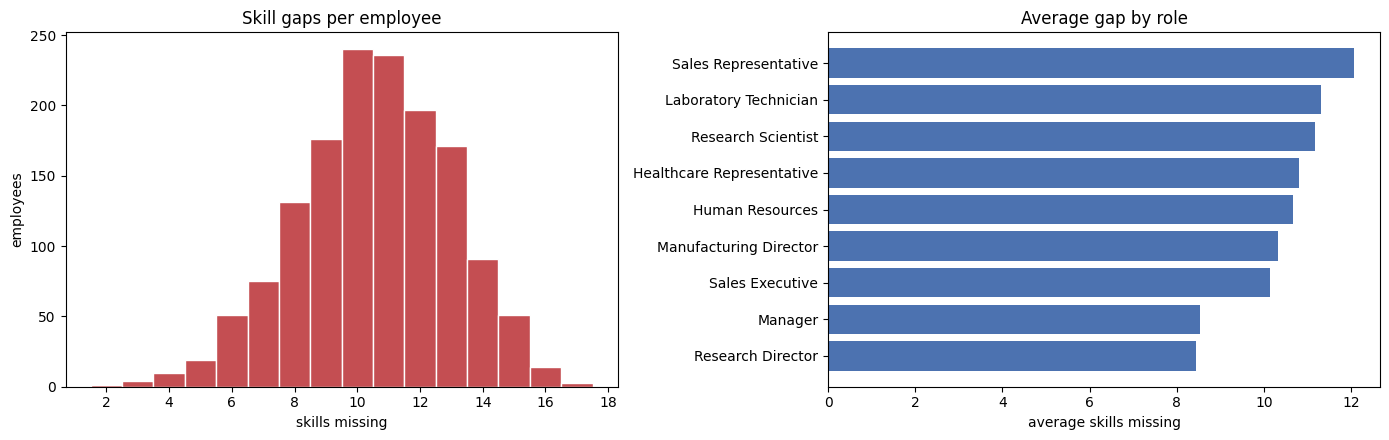

average gap: 10.6 skills | employees with no gap at all: 0


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
counts = summary["SkillGapCount"]
ax1.hist(counts, bins=range(int(counts.min()), int(counts.max()) + 2),
         color="#C44E52", edgecolor="white", align="left")
ax1.set(xlabel="skills missing", ylabel="employees", title="Skill gaps per employee")

by_role = summary.groupby("JobRole")["SkillGapCount"].mean().sort_values()
ax2.barh(by_role.index, by_role.values, color="#4C72B0")
ax2.set(xlabel="average skills missing", title="Average gap by role")
plt.tight_layout()
plt.show()

print(f"average gap: {counts.mean():.1f} skills | "
      f"employees with no gap at all: {int((counts == 0).sum())}")

## Weighting by importance

Missing two trivial skills is not the same as missing two critical ones.
`SkillGapScore` sums the O*NET importance of everything an employee lacks, so it
ranks by *severity* rather than by count.

In [7]:
summary.nlargest(10, "SkillGapScore")[
    ["EmployeeID", "JobRole", "SkillGapCount", "SkillGapScore", "TopMissingSkill"]]

,EmployeeID,JobRole,SkillGapCount,SkillGapScore,TopMissingSkill
577,802,Research Scientist,16,63.23,Microsoft Office
822,1140,Manufacturing Director,16,63.13,SAP
133,176,Sales Executive,17,63.12,Salesforce
325,442,Manufacturing Director,16,63.01,SAP
200,274,Manufacturing Director,16,62.76,SAP
989,1394,Research Scientist,16,62.11,Microsoft Office
127,167,Sales Representative,17,61.76,Salesforce
794,1103,Healthcare Representative,16,60.38,Salesforce
1125,1590,Healthcare Representative,16,60.38,Salesforce
1329,1865,Human Resources,15,59.75,Microsoft Outlook


## Count and severity are not the same ranking

In [8]:
by_count = set(summary.nlargest(50, "SkillGapCount")["EmployeeID"])
by_score = set(summary.nlargest(50, "SkillGapScore")["EmployeeID"])
overlap = len(by_count & by_score)
print(f"top 50 by gap count vs top 50 by weighted score: {overlap} in common, "
      f"{50 - overlap} differ")
print("\nRanking by raw count would send the wrong people to training first.")

top 50 by gap count vs top 50 by weighted score: 30 in common, 20 differ

Ranking by raw count would send the wrong people to training first.


## By department

In [9]:
gaps_service.gaps_by_department(gaps)

,Department,TotalGaps,DistinctSkills,EmployeesAffected
1,Research & Development,10234,45,961
2,Sales,4627,28,446
0,Human Resources,648,23,63


## Edge case: an employee with nothing on file

The defence described at the top, tested rather than asserted.

In [10]:
from app.services.skill_gap_service import compute_employee_gaps

ghost = employees.head(1).copy()
ghost["EmployeeID"] = 999999
empty_skills = skills.head(0)

ghost_gaps = compute_employee_gaps(ghost, requirements, empty_skills)
expected = len(role_requirements[ghost["JobRole"].iloc[0]])
print(f"employee with no skills on file -> {len(ghost_gaps)} gaps "
      f"(role requires {expected})")
assert len(ghost_gaps) == expected, "an employee with no skills must be missing all of them"
print("Correct: treated as missing every required skill, not as having no gap.")

employee with no skills on file -> 18 gaps (role requires 18)
Correct: treated as missing every required skill, not as having no gap.


In [11]:
gaps.to_csv(PROCESSED_FILES["skill_gaps"], index=False)
print(f"written: {PROCESSED_FILES['skill_gaps'].name}  ({len(gaps):,} rows)")

written: employee_skill_gaps.csv  (15,509 rows)
